# TD3 –LSTM text generation on Macbeth (char-level)

Exercise 2 : NLP-101 – Using LSTM to generate text
Objective: Build a LSTM-based neural network to generate text on the fly.
In this exercise, we are going to generate sentences (sonnets to be precise). To this end,
we will train a deep neural network on The tragedie of Macbeth (Shakespeare, 1606). In
this case, a char2char generator, the simplest possible use-case,  will be developed. Be
aware: we will generate old-style english 
1. Download the file macbeth.txt from Moodle. Load the file in Python and display its
content.
2. From the text, extract each character uniquely in order to build a char <-> int
dictionary. Since neural network do not understand character, we need such a
system to transform our language and the neural net language (numbers)
3. Prepare the dataset by extracting as much 50-characters-long sequences as
samples and the next character as target. Reshape and transform the dataset to
be used by a neural network
4. Build a sequential network with the following architecture:
a. A LSTM layer with 300 units, dropout of 0.2 and return sequences
b. A LSTM layer with 300 units, dropout of 0.2
c. A dense layer with as many neurons as unique characters in the dataset,
activation softmax
5. Compile and train the model with:
a.  Adam optimizer,
b. A categorical crossentropy loss function,
c. 100 epochs
d. Batch size of 30
6. Use a random seed from the data set to generate a 50-characters-long sequence
of characters


In [1]:
# Import required libraries
import os
import random

import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Data Path
ON_KAGGLE = os.path.exists('/kaggle')
KAGGLE_DATA_DIR = '/kaggle/input/mecbeth'  
DATA_DIR = KAGGLE_DATA_DIR


text_path = os.path.join(DATA_DIR, 'macbeth.txt')
print('Using text file:', text_path)
assert os.path.exists(text_path), 'macbeth.txt not found at: ' + text_path


2026-01-27 14:38:16.245279: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769524696.441007      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769524696.498133      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769524696.985845      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769524696.985881      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769524696.985884      24 computation_placer.cc:177] computation placer alr

Using text file: /kaggle/input/mecbeth/macbeth.txt


In [2]:
# 1. Load Macbeth text and inspect a small sample
with open(text_path, 'r', encoding='utf-8') as f:
    text = f.read()

print('Total characters in corpus:', len(text))
print('\nSample of the text (first 1000 chars):\n')
print(text[:1000])


Total characters in corpus: 100320

Sample of the text (first 1000 chars):

The Tragedie of Macbeth

Actus Primus. Scoena Prima.

Thunder and Lightning. Enter three Witches.

  1. When shall we three meet againe?
In Thunder, Lightning, or in Raine?
  2. When the Hurley-burley's done,
When the Battaile's lost, and wonne

   3. That will be ere the set of Sunne

   1. Where the place?
  2. Vpon the Heath

   3. There to meet with Macbeth

   1. I come, Gray-Malkin

   All. Padock calls anon: faire is foule, and foule is faire,
Houer through the fogge and filthie ayre.

Exeunt.


Scena Secunda.

Alarum within. Enter King, Malcome, Donalbaine, Lenox, with
attendants, meeting a bleeding Captaine.

  King. What bloody man is that? he can report,
As seemeth by his plight, of the Reuolt
The newest state

   Mal. This is the Serieant,
Who like a good and hardie Souldier fought
'Gainst my Captiuitie: Haile braue friend;
Say to the King, the knowledge of the Broyle,
As thou didst leaue it

   Cap

In [3]:
# 2. Build char <-> int dictionaries
chars = sorted(list(set(text)))
print('Number of unique characters:', len(chars))

char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}

# 3. Prepare dataset: 50-character-long sequences -> next character
seq_length = 50
step = 1  # move one char at a time to get many overlapping sequences

X_data = []
y_data = []
for i in range(0, len(text) - seq_length, step):
    seq_in = text[i : i + seq_length]
    seq_out = text[i + seq_length]
    X_data.append([char_to_int[ch] for ch in seq_in])
    y_data.append(char_to_int[seq_out])

n_patterns = len(X_data)
print('Number of training sequences:', n_patterns)

# reshape and normalize input
X = np.reshape(X_data, (n_patterns, seq_length, 1)).astype('float32')
X /= float(len(chars))  # simple scaling to [0, 1)

# one-hot encode targets
y = to_categorical(y_data, num_classes=len(chars))

print('Input shape:', X.shape)
print('Target shape:', y.shape)


Number of unique characters: 65
Number of training sequences: 100270
Input shape: (100270, 50, 1)
Target shape: (100270, 65)


In [4]:
# 4. Build the LSTM model
model = Sequential()
model.add(LSTM(
    300,
    return_sequences=True,
    dropout=0.2,
    input_shape=(seq_length, 1),
))
model.add(LSTM(300, dropout=0.2))
model.add(Dense(len(chars), activation='softmax'))

model.summary()

# 5. Compile and train the model
model.compile(optimizer='adam', loss='categorical_crossentropy')

EPOCHS = 100  # on Kaggle GPU you can keep 100; reduce if it is too slow
BATCH_SIZE = 30

history = model.fit(
    X,
    y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)


I0000 00:00:1769524711.857953      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 300)        │       362,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 300)            │       721,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 65)             │        19,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,103,165 (4.21 MB)

 Trainable params: 1,103,165 (4.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


I0000 00:00:1769524716.483118      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


3343/3343 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 3.0929
Epoch 2/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 2.7780
Epoch 3/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 2.6979
Epoch 4/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 2.6344
Epoch 5/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 2.5623
Epoch 6/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 2.4989
Epoch 7/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 2.4291
Epoch 8/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 2.3943
Epoch 9/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 2.3421
Epoch 10/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 2.2939
Epoch 11/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 2.2530
Epoch 12/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 2.2208
Epoch 13/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 2.1723
Epoch 14/100
3343/3343 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 2.1378

In [5]:
# 6. Generate text from a random 50-character seed
start_index = random.randint(0, len(text) - seq_length - 1)
seed_text = text[start_index : start_index + seq_length]

print('Seed text (50 chars):\n')
print(repr(seed_text))

pattern = [char_to_int[ch] for ch in seed_text]
generated = ''
num_chars_to_generate = 50

for i in range(num_chars_to_generate):
    x_pred = np.reshape(pattern, (1, seq_length, 1)).astype('float32')
    x_pred /= float(len(chars))

    preds = model.predict(x_pred, verbose=0)[0]
    next_index = np.argmax(preds)  # greedy sampling
    next_char = int_to_char[next_index]

    generated += next_char
    pattern.append(next_index)
    pattern = pattern[1:]  # slide window by one

print('\nGenerated continuation (50 chars):\n')
print(repr(generated))

print('\nFull seed + generated text:\n')
print(seed_text + generated)


Seed text (50 chars):

'ren Scepter in my Gripe,\nThence to be wrencht with'

Generated continuation (50 chars):

" tel's atrhte\nOu man a ronrns: initne Duelgsos, fn"

Full seed + generated text:

ren Scepter in my Gripe,
Thence to be wrencht with tel's atrhte
Ou man a ronrns: initne Duelgsos, fn


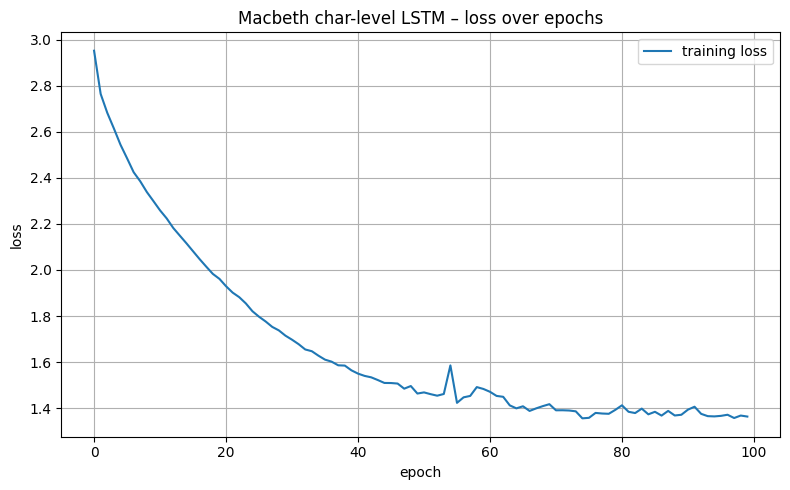

In [6]:
import matplotlib.pyplot as plt

# history is the object returned by model.fit()
history_dict = history.history

loss = history_dict.get("loss", [])
val_loss = history_dict.get("val_loss", [])

plt.figure(figsize=(8, 5))
plt.plot(loss, label="training loss")
if len(val_loss) > 0:
    plt.plot(val_loss, label="validation loss")

plt.title("Macbeth char-level LSTM – loss over epochs")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## My Observation

after some training epochs, i see the loss going down, but not in a perfectly straight line. when i look at the generated text, i notice a lot of old‑style words and strange spellings that feel similar to the original shakespeare text, but many sentences do not really make clear sense.

sometimes the network repeats little pieces of phrases again and again. that tells me the model has learned local character patterns (which letters or groups of letters often come together), but it still struggles to keep a long and coherent story in mind.

if i change the sampling strategy (for example by using temperature and not always picking the argmax), the text becomes more surprising and creative, but also more messy. so there is a small trade‑off between creativity and readability in this character‑level generation.
